# **Setup Environment**

In [ ]:
import shutil
import os

# List of directories to delete
dirs_to_delete = [
    "/content/logs_t5_hs",
    "/content/logs_t5_trac",
    "/content/mt5_hate_speech_model_20250415_0758",
    "/content/mt5_hate_speech_model_20250415_0801",
    "/content/t5_hate_speech_model_20250415_0748"
]

for dir_path in dirs_to_delete:
    if os.path.exists(dir_path):
        shutil.rmtree(dir_path)
        print(f"✅ Deleted: {dir_path}")
    else:
        print(f"⚠️ Not found: {dir_path}")

⚠️ Not found: /content/logs_t5_hs
⚠️ Not found: /content/logs_t5_trac
⚠️ Not found: /content/mt5_hate_speech_model_20250415_0758
⚠️ Not found: /content/mt5_hate_speech_model_20250415_0801
✅ Deleted: /content/mt5_hate_speech_model_20250415_1444


In [ ]:
!pip install transformers datasets

  Using cached datasets-3.5.0-py3-none-any.whl.metadata (19 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.2/491.2 kB 18.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.9/183.9 kB 17.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.5/143.5 kB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.8/194.8 kB 17.7 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2025.3.0
    Uninstalling fsspec-2025.3.0:
      Successfully uninstalled fsspec-2025.3.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torch 2.6.0+cu124 requires nvidia-cublas-cu12==12.4.5.8; platform_system == "Linux" and platform_machine == "x86_64", but you have nvidia-cublas-cu12 12.5.3.2 which is incompatible.
torch 2.6.0+c

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DistilBertModel,
    DistilBertPreTrainedModel
)
import torch
import numpy as np
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from torch import nn
from tqdm import tqdm

###**1. Data Preparation**

In [ ]:
def load_dataset(file_path):
    df = pd.read_csv(file_path)
    # Ensure we only keep relevant columns and rename for consistency
    df = df[['ID', 'Text', 'Label']].rename(columns={'Text': 'text', 'Label': 'label'})
    return df

# Load your dataset
df = load_dataset('/content/cleaned_agr_hi_train.csv')

# Split data (80% train, 10% val, 10% test)
train_df, temp_df = train_test_split(df, test_size=0.2, random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42)

print(f"Training samples: {len(train_df)}")
print(f"Validation samples: {len(val_df)}")
print(f"Test samples: {len(test_df)}\n")

# Convert to HuggingFace Dataset format
train_dataset = Dataset.from_pandas(train_df)
val_dataset = Dataset.from_pandas(val_df)
test_dataset = Dataset.from_pandas(test_df)

Training samples: 9598
Validation samples: 1200
Test samples: 1200



### **2. Define Metrics and Tokenization**

In [ ]:
def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='binary')
    acc = accuracy_score(labels, preds)
    return {
        'accuracy': acc,
        'f1': f1,
        'precision': precision,
        'recall': recall
    }

def tokenize_function(examples, tokenizer):
    return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=128)

# Custom callback for verbose output
from transformers import TrainerCallback

class ProgressCallback(TrainerCallback):
    def on_epoch_end(self, args, state, control, **kwargs):
        print(f"\nEpoch {state.epoch} completed")
        print(f"Training Loss: {state.log_history[-1]['loss']:.4f}")
        if 'eval_loss' in state.log_history[-1]:
            print(f"Validation Loss: {state.log_history[-1]['eval_loss']:.4f}")
            print(f"Validation Accuracy: {state.log_history[-1]['eval_accuracy']:.4f}")
            print(f"Validation F1: {state.log_history[-1]['eval_f1']:.4f}")

### **3. Model Implementations**


In [ ]:
# A. IndicBERT
def train_indicbert(train_dataset, val_dataset):
    print("\n" + "="*50)
    print("Training IndicBERT Model")
    print("="*50 + "\n")

    model_name = "ai4bharat/indic-bert"
    tokenizer = AutoTokenizer.from_pretrained(model_name)

    # Tokenize datasets
    print("Tokenizing datasets...")
    tokenized_train = train_dataset.map(lambda x: tokenize_function(x, tokenizer), batched=True)
    tokenized_val = val_dataset.map(lambda x: tokenize_function(x, tokenizer), batched=True)

    model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)

    training_args = TrainingArguments(
        output_dir="./indicbert_results",
        evaluation_strategy="epoch",
        save_strategy="epoch",
        per_device_train_batch_size=8,
        per_device_eval_batch_size=8,
        num_train_epochs=3,
        learning_rate=2e-5,
        weight_decay=0.01,
        load_best_model_at_end=True,
        metric_for_best_model="f1",
        logging_strategy="epoch",
        logging_dir="./indicbert_logs",
        report_to="none",
        disable_tqdm=False,  # Show progress bars
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=tokenized_train,
        eval_dataset=tokenized_val,
        compute_metrics=compute_metrics,
        callbacks=[ProgressCallback()],
    )

    print("\nStarting training...")
    trainer.train()
    print("\nTraining completed!")
    return trainer, tokenizer

In [ ]:
# B. XLM-RoBERTa
def train_xlmr(train_dataset, val_dataset):
    model_name = "xlm-roberta-base"
    tokenizer = AutoTokenizer.from_pretrained(model_name)

    tokenized_train = train_dataset.map(lambda x: tokenize_function(x, tokenizer), batched=True)
    tokenized_val = val_dataset.map(lambda x: tokenize_function(x, tokenizer), batched=True)

    model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)

    training_args = TrainingArguments(
        output_dir="./xlmr_results",
        evaluation_strategy="epoch",
        save_strategy="epoch",
        per_device_train_batch_size=16,
        per_device_eval_batch_size=16,
        num_train_epochs=4,
        learning_rate=1e-5,
        weight_decay=0.01,
        load_best_model_at_end=True,
        metric_for_best_model="f1",
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=tokenized_train,
        eval_dataset=tokenized_val,
        compute_metrics=compute_metrics,
    )

    trainer.train()
    return trainer, tokenizer

In [ ]:
# C. DistilBERT with Custom Head
class DistilBertWithCustomHead(DistilBertPreTrainedModel):
    def __init__(self, config):
        super().__init__(config)
        self.distilbert = DistilBertModel(config)
        self.dropout = nn.Dropout(0.1)
        self.classifier = nn.Linear(config.dim, 2)
        self.init_weights()

    def forward(self, input_ids=None, attention_mask=None, labels=None):
        outputs = self.distilbert(input_ids, attention_mask=attention_mask)
        pooled_output = outputs[0][:, 0]
        pooled_output = self.dropout(pooled_output)
        logits = self.classifier(pooled_output)

        loss = None
        if labels is not None:
            loss_fct = nn.CrossEntropyLoss()
            loss = loss_fct(logits.view(-1, 2), labels.view(-1))

        return {'loss': loss, 'logits': logits}

def train_distilbert_custom(train_dataset, val_dataset):
    model_name = "distilbert-base-multilingual-cased"
    tokenizer = AutoTokenizer.from_pretrained(model_name)

    tokenized_train = train_dataset.map(lambda x: tokenize_function(x, tokenizer), batched=True)
    tokenized_val = val_dataset.map(lambda x: tokenize_function(x, tokenizer), batched=True)

    model = DistilBertWithCustomHead.from_pretrained(model_name)

    training_args = TrainingArguments(
        output_dir="./distilbert_custom_results",
        evaluation_strategy="epoch",
        save_strategy="epoch",
        per_device_train_batch_size=32,
        per_device_eval_batch_size=32,
        num_train_epochs=5,
        learning_rate=3e-5,
        weight_decay=0.01,
        load_best_model_at_end=True,
        metric_for_best_model="f1",
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=tokenized_train,
        eval_dataset=tokenized_val,
        compute_metrics=compute_metrics,
    )

    trainer.train()
    return trainer, tokenizer

In [ ]:
# 4. Train and Evaluate Models
print("Training IndicBERT...")
indicbert_trainer, indicbert_tokenizer = train_indicbert(train_dataset, val_dataset)

Training IndicBERT...

Training IndicBERT Model

Tokenizing datasets...


Map:   0%|          | 0/9598 [00:00<?, ? examples/s]

Map:   0%|          | 0/1200 [00:00<?, ? examples/s]

Some weights of AlbertForSequenceClassification were not initialized from the model checkpoint at ai4bharat/indic-bert and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.11/dist-packages/transformers/training_args.py:1611: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(



Starting training...


RuntimeError: CUDA error: device-side assert triggered
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


In [ ]:
print("\nTraining XLM-RoBERTa...")
xlmr_trainer, xlmr_tokenizer = train_xlmr(train_dataset, val_dataset)

print("\nTraining DistilBERT with Custom Head...")
distilbert_trainer, distilbert_tokenizer = train_distilbert_custom(train_dataset, val_dataset)

In [ ]:
# 5. Evaluation Function
def evaluate_model(trainer, tokenizer, dataset):
    tokenized_test = dataset.map(lambda x: tokenize_function(x, tokenizer), batched=True)
    predictions = trainer.predict(tokenized_test)
    metrics = compute_metrics(predictions)
    print(f"Accuracy: {metrics['accuracy']:.4f}")
    print(f"F1 Score: {metrics['f1']:.4f}")
    print(f"Precision: {metrics['precision']:.4f}")
    print(f"Recall: {metrics['recall']:.4f}")
    return metrics

# Evaluate all models
print("\nEvaluating IndicBERT...")
indicbert_metrics = evaluate_model(indicbert_trainer, indicbert_tokenizer, test_dataset)

print("\nEvaluating XLM-RoBERTa...")
xlmr_metrics = evaluate_model(xlmr_trainer, xlmr_tokenizer, test_dataset)

print("\nEvaluating DistilBERT with Custom Head...")
distilbert_metrics = evaluate_model(distilbert_trainer, distilbert_tokenizer, test_dataset)

# 6. Save Best Model
best_model = xlmr_trainer.model  # Replace with your best performing model
best_tokenizer = xlmr_tokenizer

best_model.save_pretrained("./best_model")
best_tokenizer.save_pretrained("./best_model")

# 7. Inference Example
from transformers import pipeline

classifier = pipeline("text-classification", model="./best_model", tokenizer="./best_model")

sample_texts = [
    "Bhai 60sal pehle desh me kya tha pehle pta kro desh waise ka waise kaise hai",
    "जय मोदीराज",
    "This is a normal sentence without any hate speech"
]

for text in sample_texts:
    result = classifier(text)
    print(f"\nText: {text}")
    print(f"Prediction: {'Hate Speech' if result[0]['label'] == 'LABEL_1' else 'Normal'}")
    print(f"Confidence: {result[0]['score']:.4f}")

# **Research Paper Implimentation**

### **Data Preprocessing with MOH**

In [ ]:
!sudo apt-get install -y enchant-2 hunspell-en-us
!pip install pyenchant Levenshtein pandas

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  aspell aspell-en dictionaries-common libaspell15 libenchant-2-2
  libhunspell-1.7-0 libtext-iconv-perl
Suggested packages:
  aspell-doc spellutils wordlist hunspell openoffice.org-hunspell
  | openoffice.org-core libenchant-2-voikko
The following NEW packages will be installed:
  aspell aspell-en dictionaries-common enchant-2 hunspell-en-us libaspell15
  libenchant-2-2 libhunspell-1.7-0 libtext-iconv-perl
0 upgraded, 9 newly installed, 0 to remove and 30 not upgraded.
Need to get 1,431 kB of archives.
After this operation, 5,501 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/main amd64 libtext-iconv-perl amd64 1.7-7build3 [14.3 kB]
Get:2 http://archive.ubuntu.com/ubuntu jammy/main amd64 libaspell15 amd64 0.60.8-4build1 [325 kB]
Get:3 http://archive.ubuntu.com/ubuntu jammy/main amd64 dictionaries-c

In [ ]:
# Step 2: Import with Robust Error Handling
import os
import pandas as pd
import re
from Levenshtein import ratio

try:
    import enchant
    print("Enchant version:", enchant.__version__)
except ImportError:
    print("Falling back to simplified English check")
    enchant = None

# Step 3: Data Loading with Checkpoint Resume
def load_data_with_resume(filepath, columns, checkpoint_path):
    if os.path.exists(checkpoint_path):
        print(f"Loading checkpoint: {checkpoint_path}")
        return pd.read_csv(checkpoint_path)
    else:
        print(f"Loading fresh data: {filepath}")
        df = pd.read_csv(filepath, names=columns, encoding='utf-8')
        df.to_csv(checkpoint_path, index=False)
        return df

# Load datasets with checkpointing
trac = load_data_with_resume(
    'agr_hi_train.csv',
    ['id', 'text', 'label'],
    'trac_checkpoint.csv'
)

hs = load_data_with_resume(
    'hate_speech.csv',
    ['text', 'label'],
    'hs_checkpoint.csv'
)

# Step 4: Knowledge Base Loading
kb = {}
try:
    with open('KB_Dict.txt', 'r', encoding='utf-8') as f:
        for line in f:
            if ':' in line:
                key, value = line.strip().split(':', 1)
                kb[key.strip()] = value.strip()
    print(f"Loaded {len(kb)} KB entries")
except Exception as e:
    print(f"KB loading failed: {str(e)}")

# Step 5: Enhanced Text Cleaning
def clean_text(text):
    if not isinstance(text, str) or pd.isna(text):
        return ""
    text = re.sub(r'http\S+|@\w+|[^\w\s]', '', text)
    text = re.sub(r'(.)\1{2,}', r'\1\1', text)
    return text.strip()

# Step 6: Fault-Tolerant Transliteration
class Transliterator:
    def __init__(self):
        self.en_dict = None
        self.common_english = {"the", "and", "you", "that", "this"}  # Add more

        if enchant:
            try:
                self.en_dict = enchant.Dict("en_US")
            except:
                print("Enchant dictionary failed, using fallback")

    def is_english(self, word):
        if self.en_dict:
            return self.en_dict.check(word)
        return word.lower() in self.common_english

    def transliterate(self, text, checkpoint_file=None):
        if not text:
            return ""

        words = text.split()
        processed = []
        for i, word in enumerate(words):
            if self.is_english(word):
                processed.append(word)
            elif word in kb:
                processed.append(kb[word])
            else:
                # Find best match with progress saving
                best_match = None
                max_sim = 0.7
                for kb_word in kb:
                    sim = ratio(word, kb_word)
                    if sim > max_sim:
                        max_sim = sim
                        best_match = kb_word
                processed.append(kb.get(best_match, word))

            # Save progress every 100 words
            if checkpoint_file and i % 100 == 0:
                with open(checkpoint_file, 'w') as f:
                    f.write(' '.join(processed + words[i+1:]))
        return ' '.join(processed)

# Step 7: Process Data with Auto-Resume
def process_dataset(df, text_col, output_col, checkpoint_file):
    transliterator = Transliterator()

    if os.path.exists(checkpoint_file):
        print(f"Resuming from checkpoint: {checkpoint_file}")
        with open(checkpoint_file, 'r') as f:
            saved = f.read().split()
        processed = saved
        start_idx = len(saved)
    else:
        processed = []
        start_idx = 0

    for idx in range(start_idx, len(df)):
        text = clean_text(df.at[idx, text_col])
        result = transliterator.transliterate(text)
        processed.append(result)

        # Save checkpoint every 50 entries
        if idx % 50 == 0:
            df[output_col] = processed + ['']*(len(df)-len(processed))
            df.to_csv(f"temp_{checkpoint_file}", index=False)
            os.replace(f"temp_{checkpoint_file}", checkpoint_file)

    df[output_col] = processed
    if os.path.exists(checkpoint_file):
        os.remove(checkpoint_file)
    return df

# Process datasets with individual checkpoints
trac = process_dataset(trac, 'text', 'moh_text', 'trac_translit_checkpoint.txt')
hs = process_dataset(hs, 'text', 'moh_text', 'hs_translit_checkpoint.txt')

# Step 8: Final Save
trac.to_csv('final_trac_processed.csv', index=False)
hs.to_csv('final_hs_processed.csv', index=False)

# Step 9: Model Ready Data Export
print("Processing complete! Download files:")
from google.colab import files
files.download('final_trac_processed.csv')
files.download('final_hs_processed.csv')

Enchant version: 3.2.2
Loading fresh data: agr_hi_train.csv
Loading fresh data: hate_speech.csv
Loaded 72582 KB entries
Processing complete! Download files:


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import pandas as pd
import re
import os

# === CONFIG: Paths ===
trac_path = "final_trac_processed.csv"
hs_path = "final_hs_processed.csv"
clean_trac_path = "final_trac_cleaned.csv"
clean_hs_path = "final_hs_cleaned.csv"

# === Cleaning function ===
def clean_text(text):
    if not isinstance(text, str):
        return text
    text = re.sub(r"http\S+", "", text)       # Remove hyperlinks
    text = re.sub(r"@\w+", "", text)          # Remove mentions
    text = text.replace("#", "")              # Remove hashtags
    return text.strip()

# === Load & Clean function ===
def load_and_clean(filepath, save_as):
    print(f"Cleaning {filepath}...")
    df = pd.read_csv(filepath)

    # Apply cleaning to 'text' column
    if 'text' in df.columns:
        df['text'] = df['text'].apply(clean_text)
    else:
        raise ValueError("'text' column not found!")

    # Check for text fields with comma inside quotes
    quoted_commas = df['text'].str.contains(r'^".*?,.*?"', regex=True).sum()
    print(f"🔍 Entries with commas inside quotes: {quoted_commas}")

    # Save cleaned file
    df.to_csv(save_as, index=False)
    print(f"✅ Cleaned file saved as {save_as}\n")

# === Run cleaning ===
load_and_clean(trac_path, clean_trac_path)
load_and_clean(hs_path, clean_hs_path)

Cleaning final_trac_processed.csv...
🔍 Entries with commas inside quotes: 2
✅ Cleaned file saved as final_trac_cleaned.csv

Cleaning final_hs_processed.csv...
🔍 Entries with commas inside quotes: 0
✅ Cleaned file saved as final_hs_cleaned.csv



### **Model Training**

####**Raw Indic-Bert**

Training binary hate speech classification model...


config.json:   0%|          | 0.00/507 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/5.65M [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/135M [00:00<?, ?B/s]

Some weights of AlbertForSequenceClassification were not initialized from the model checkpoint at ai4bharat/indic-bert and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


...

Val Loss: 2.9106 | Accuracy: 0.6528 | F1: 0.6560 | Precision: 0.6591 | Recall: 0.6536

Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.72      0.74       610
           1       0.48      0.51      0.50       305

    accuracy                           0.65       915
   macro avg       0.61      0.62      0.62       915
weighted avg       0.66      0.65      0.66       915


Epoch 30/30
----------


Training: 100%|██████████| 229/229 [01:16<00:00,  3.00it/s]


Train Loss: 0.0012 | Accuracy: 0.9989 | F1: 0.9997 | Precision: 0.9997 | Recall: 0.9997


Evaluating: 100%|██████████| 58/58 [00:07<00:00,  7.81it/s]


Val Loss: 2.9053 | Accuracy: 0.6474 | F1: 0.6500 | Precision: 0.6522 | Recall: 0.6481

Classification Report:
              precision    recall  f1-score   support

           0       0.74      0.72      0.73       610
           1       0.47      0.50      0.48       305

    accuracy                           0.65       915
   macro avg       0.61      0.61      0.61       915
weighted avg       0.65      0.65      0.65       915




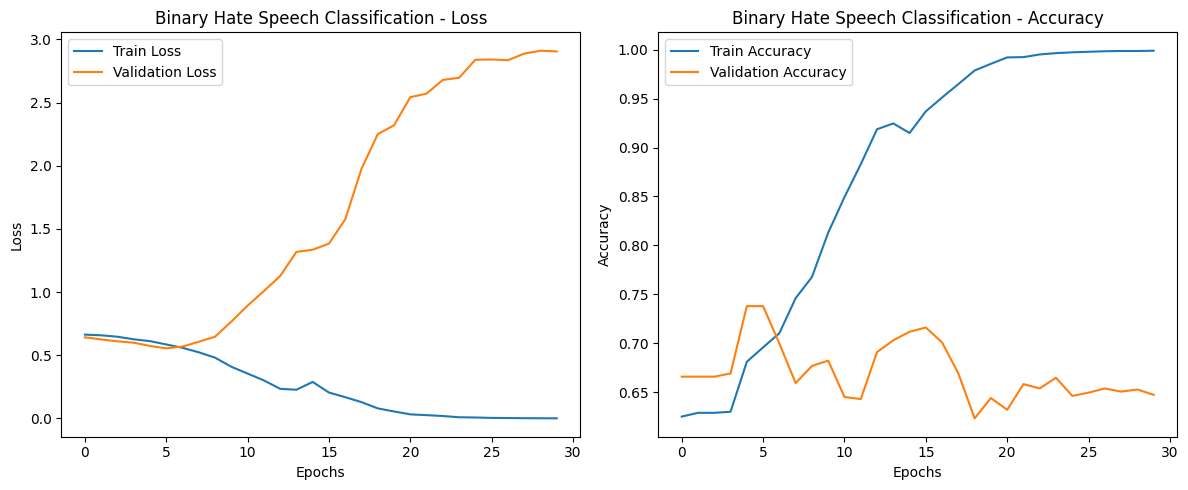


Training aggressive hate speech classification model...


Some weights of AlbertForSequenceClassification were not initialized from the model checkpoint at ai4bharat/indic-bert and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch 1/30
----------


Training: 100%|██████████| 600/600 [03:21<00:00,  2.98it/s]


Train Loss: 1.0162 | Accuracy: 0.4247 | F1: 0.3994 | Precision: 0.4508 | Recall: 0.4247


...

Val Loss: 3.9510 | Accuracy: 0.5613 | F1: 0.5593 | Precision: 0.5650 | Recall: 0.5613

Classification Report:
              precision    recall  f1-score   support

           0       0.53      0.59      0.56       995
           1       0.58      0.59      0.58       974
           2       0.61      0.42      0.50       431

    accuracy                           0.56      2400
   macro avg       0.57      0.53      0.55      2400
weighted avg       0.56      0.56      0.56      2400


Epoch 30/30
----------


Training: 100%|██████████| 600/600 [03:21<00:00,  2.98it/s]


Train Loss: 0.0386 | Accuracy: 0.9918 | F1: 0.9918 | Precision: 0.9918 | Recall: 0.9918


Evaluating: 100%|██████████| 150/150 [00:19<00:00,  7.80it/s]


Val Loss: 3.9437 | Accuracy: 0.5654 | F1: 0.5642 | Precision: 0.5689 | Recall: 0.5654

Classification Report:
              precision    recall  f1-score   support

           0       0.54      0.62      0.58       995
           1       0.59      0.55      0.57       974
           2       0.59      0.46      0.52       431

    accuracy                           0.57      2400
   macro avg       0.57      0.55      0.56      2400
weighted avg       0.57      0.57      0.56      2400




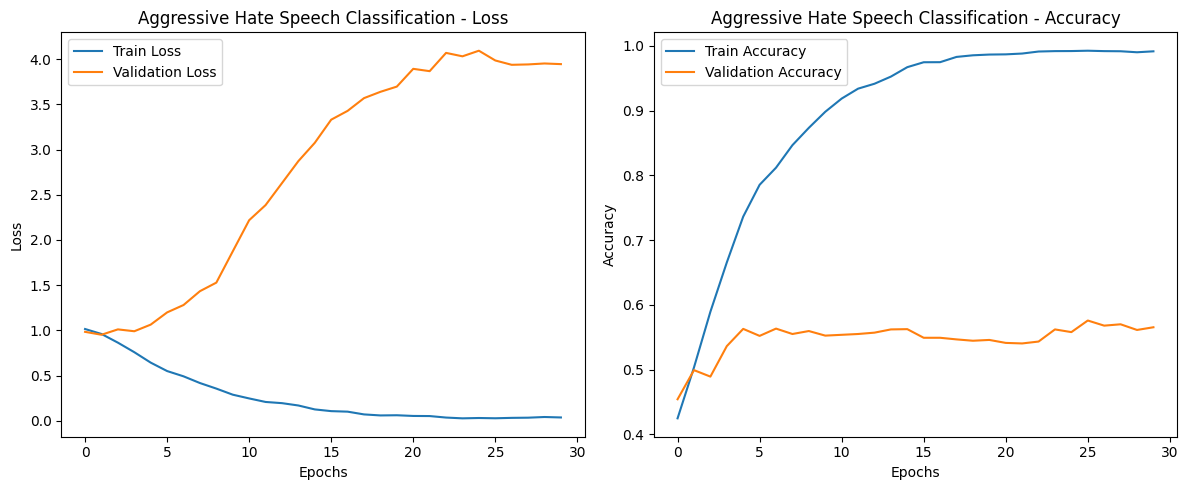

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, f1_score, precision_score, recall_score
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from torch.optim import AdamW
from transformers import get_linear_schedule_with_warmup
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Configuration
MODEL_NAME = 'ai4bharat/indic-bert'
MAX_LEN = 128
BATCH_SIZE = 16
EPOCHS = 30
LEARNING_RATE = 2e-5
NUM_WARMUP_STEPS = 0

# Custom Dataset Class with improved label handling
class HinglishDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

        # First handle NaN values
        self.labels = [label if not pd.isna(label) else -1 for label in self.labels]

        # Convert labels to integers and handle potential issues
        try:
            self.labels = [int(float(label)) if str(label).strip() not in ['', 'nan', 'NaN'] else -1 for label in self.labels]
        except (ValueError, TypeError) as e:
            print(f"Error converting labels to integers: {e}")
            # If conversion fails, create a mapping from unique labels to integers
            unique_labels = sorted(list(set([label for label in self.labels if not pd.isna(label)])))
            self.label_map = {label: i for i, label in enumerate(unique_labels)}
            self.labels = [self.label_map.get(label, -1) for label in self.labels]

        # Filter out samples with invalid labels (-1)
        valid_indices = [i for i, label in enumerate(self.labels) if label != -1]
        self.texts = [self.texts[i] for i in valid_indices]
        self.labels = [self.labels[i] for i in valid_indices]

        if len(valid_indices) < len(self.labels):
            print(f"Warning: Removed {len(self.labels) - len(valid_indices)} samples with invalid labels")

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]

        encoding = self.tokenizer.encode_plus(
            text,
            add_special_tokens=True,
            max_length=self.max_len,
            return_token_type_ids=False,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'label': torch.tensor(label, dtype=torch.long)
        }

def load_data(file_path, task_type='binary'):
    df = pd.read_csv(file_path)

    # Check for NaN values in the text column
    if df['moh_text'].isna().any():
        print(f"Warning: Found {df['moh_text'].isna().sum()} rows with NaN text. These will be removed.")
        df = df.dropna(subset=['moh_text'])

    if task_type == 'binary':
        # Binary classification with robust label handling
        df = df[['moh_text', 'label']].copy()

        # Clean and convert labels
        df['label'] = df['label'].astype(str).str.strip().str.lower()
        valid_labels = {'yes', 'no', '1', '0', 'true', 'false'}

        # Filter out rows with invalid labels
        original_size = len(df)
        df = df[df['label'].isin(valid_labels)]
        if len(df) < original_size:
            print(f"Warning: Removed {original_size - len(df)} rows with invalid labels")

        # Convert to binary labels (1 for hate speech, 0 for not)
        df['label'] = df['label'].map({'yes': 1, 'no': 0, '1': 1, '0': 0, 'true': 1, 'false': 0})

    elif task_type == 'aggressive':
        # Aggressive hate speech classification with robust label handling
        df = df[['moh_text', 'label']].copy()

        # Clean and convert labels
        df['label'] = df['label'].astype(str).str.strip().str.upper()
        valid_labels = {'CAG', 'OAG', 'NAG', '0', '1', '2'}

        # Filter out rows with invalid labels
        original_size = len(df)
        df = df[df['label'].isin(valid_labels)]
        if len(df) < original_size:
            print(f"Warning: Removed {original_size - len(df)} rows with invalid labels")

        # Convert to numerical labels
        label_dict = {'CAG': 0, 'OAG': 1, 'NAG': 2, '0': 0, '1': 1, '2': 2}
        df['label'] = df['label'].map(label_dict)

    # Check for any remaining NaN labels
    if df['label'].isna().any():
        print(f"Warning: Found {df['label'].isna().sum()} rows with NaN labels after conversion")
        df = df.dropna(subset=['label'])

    # Convert labels to integers
    df['label'] = df['label'].astype(int)

    return df

# Function to create data loaders
def create_data_loader(df, tokenizer, max_len, batch_size, label_col='label'):
    ds = HinglishDataset(
        texts=df['moh_text'].values,
        labels=df[label_col].values,
        tokenizer=tokenizer,
        max_len=max_len
    )

    return DataLoader(
        ds,
        batch_size=batch_size,
        num_workers=4
    )

# Function to train the model
def train_epoch(model, data_loader, optimizer, device, scheduler, n_examples):
    model = model.train()
    losses = []
    correct_predictions = 0
    all_preds = []
    all_labels = []

    for d in tqdm(data_loader, desc="Training"):
        input_ids = d['input_ids'].to(device)
        attention_mask = d['attention_mask'].to(device)
        labels = d['label'].to(device)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )

        loss = outputs.loss
        logits = outputs.logits

        _, preds = torch.max(logits, dim=1)
        correct_predictions += torch.sum(preds == labels)
        losses.append(loss.item())

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()
        optimizer.zero_grad()

    accuracy = correct_predictions.double() / n_examples
    avg_loss = np.mean(losses)

    # Calculate additional metrics
    f1 = f1_score(all_labels, all_preds, average='weighted')
    precision = precision_score(all_labels, all_preds, average='weighted')
    recall = recall_score(all_labels, all_preds, average='weighted')

    return accuracy, avg_loss, f1, precision, recall

# Function to evaluate the model
def eval_model(model, data_loader, device, n_examples):
    model = model.eval()
    losses = []
    correct_predictions = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for d in tqdm(data_loader, desc="Evaluating"):
            input_ids = d['input_ids'].to(device)
            attention_mask = d['attention_mask'].to(device)
            labels = d['label'].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )

            loss = outputs.loss
            logits = outputs.logits

            _, preds = torch.max(logits, dim=1)
            correct_predictions += torch.sum(preds == labels)
            losses.append(loss.item())

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    accuracy = correct_predictions.double() / n_examples
    avg_loss = np.mean(losses)

    # Calculate additional metrics
    f1 = f1_score(all_labels, all_preds, average='weighted')
    precision = precision_score(all_labels, all_preds, average='weighted')
    recall = recall_score(all_labels, all_preds, average='weighted')

    return accuracy, avg_loss, f1, precision, recall, all_preds, all_labels

# Function to plot training metrics
def plot_metrics(history, task_name):
    plt.figure(figsize=(12, 5))

    # Plot loss
    plt.subplot(1, 2, 1)
    plt.plot(history['train_loss'], label='Train Loss')
    plt.plot(history['val_loss'], label='Validation Loss')
    plt.title(f'{task_name} - Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    # Plot accuracy
    plt.subplot(1, 2, 2)
    plt.plot(history['train_acc'], label='Train Accuracy')
    plt.plot(history['val_acc'], label='Validation Accuracy')
    plt.title(f'{task_name} - Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.tight_layout()
    plt.show()

# Main training function
def train_model(df_train, df_val, label_col='label', num_labels=2, model_save_path='indic_bert_hate_speech.bin', task_name='Binary Classification'):
    # Load tokenizer and model
    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
    model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=num_labels)
    model = model.to(device)

    # Create data loaders
    train_data_loader = create_data_loader(df_train, tokenizer, MAX_LEN, BATCH_SIZE, label_col)
    val_data_loader = create_data_loader(df_val, tokenizer, MAX_LEN, BATCH_SIZE, label_col)

    # Optimizer and scheduler
    optimizer = AdamW(model.parameters(), lr=LEARNING_RATE)
    total_steps = len(train_data_loader) * EPOCHS
    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=NUM_WARMUP_STEPS,
        num_training_steps=total_steps
    )

    # Training loop
    best_accuracy = 0
    history = {
        'train_acc': [], 'train_loss': [], 'train_f1': [], 'train_precision': [], 'train_recall': [],
        'val_acc': [], 'val_loss': [], 'val_f1': [], 'val_precision': [], 'val_recall': [],
        'epoch': []
    }

    for epoch in range(EPOCHS):
        print(f'Epoch {epoch + 1}/{EPOCHS}')
        print('-' * 10)

        train_acc, train_loss, train_f1, train_precision, train_recall = train_epoch(
            model,
            train_data_loader,
            optimizer,
            device,
            scheduler,
            len(df_train)
        )

        print(f'Train Loss: {train_loss:.4f} | Accuracy: {train_acc:.4f} | F1: {train_f1:.4f} | Precision: {train_precision:.4f} | Recall: {train_recall:.4f}')

        val_acc, val_loss, val_f1, val_precision, val_recall, val_preds, val_labels = eval_model(
            model,
            val_data_loader,
            device,
            len(df_val)
        )

        print(f'Val Loss: {val_loss:.4f} | Accuracy: {val_acc:.4f} | F1: {val_f1:.4f} | Precision: {val_precision:.4f} | Recall: {val_recall:.4f}')
        print('\nClassification Report:')
        print(classification_report(val_labels, val_preds))
        print()

        # Store metrics
        history['train_acc'].append(train_acc.cpu().numpy())
        history['train_loss'].append(train_loss)
        history['train_f1'].append(train_f1)
        history['train_precision'].append(train_precision)
        history['train_recall'].append(train_recall)

        history['val_acc'].append(val_acc.cpu().numpy())
        history['val_loss'].append(val_loss)
        history['val_f1'].append(val_f1)
        history['val_precision'].append(val_precision)
        history['val_recall'].append(val_recall)
        history['epoch'].append(epoch + 1)

        if val_acc > best_accuracy:
            torch.save(model.state_dict(), model_save_path)
            best_accuracy = val_acc

    # Plot metrics
    plot_metrics({
        'train_loss': history['train_loss'],
        'val_loss': history['val_loss'],
        'train_acc': history['train_acc'],
        'val_acc': history['val_acc']
    }, task_name)

    return history

# Function to encode labels for multi-class classification
def encode_labels(df, label_col, label_dict):
    df[label_col] = df[label_col].map(label_dict)
    return df

# Function to load and preprocess data
def load_data(file_path, task_type='binary'):
    df = pd.read_csv(file_path)

    if task_type == 'binary':
        # Binary classification
        df = df[['moh_text', 'label']]
        df['label'] = df['label'].map({'yes': 1, 'no': 0})
    elif task_type == 'aggressive':
        # Aggressive hate speech classification
        label_dict = {'CAG': 0, 'OAG': 1, 'NAG': 2}
        df = encode_labels(df, 'label', label_dict)
        df = df[['moh_text', 'label']]

    return df

# Function to run training for both tasks
def run_training():
    # Binary classification
    print("="*50)
    print("Training binary hate speech classification model...")
    print("="*50)
    binary_df = load_data('final_hs_cleaned.csv', task_type='binary')
    df_train, df_val = train_test_split(binary_df, test_size=0.2, random_state=42)
    binary_history = train_model(df_train, df_val, num_labels=2,
                               model_save_path='indic_bert_binary_hate_speech.bin',
                               task_name='Binary Hate Speech Classification')

    # Aggressive hate speech classification
    print("="*50)
    print("\nTraining aggressive hate speech classification model...")
    print("="*50)
    aggressive_df = load_data('final_trac_cleaned.csv', task_type='aggressive')
    df_train, df_val = train_test_split(aggressive_df, test_size=0.2, random_state=42)
    aggressive_history = train_model(df_train, df_val, num_labels=3,
                                   model_save_path='indic_bert_aggressive_hate_speech.bin',
                                   task_name='Aggressive Hate Speech Classification')

    return binary_history, aggressive_history

# Run the training
binary_history, aggressive_history = run_training()

####**Fine Tuning of Indic Bert and added 3 convolutional layers with attention**

In [ ]:
!pip install textaugment

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 4.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.7/26.7 MB 89.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 114.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.6/38.6 MB 17.0 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
  Attempting uninstall: scipy
    Found existing installation: scipy 1.14.1
    Uninstalling scipy-1.14.1:
      Successfully uninstalled scipy-1.14.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
thinc 8.3.6 requires numpy<3.0.0,>=2.0.0, but you have numpy 1.26.4 which is incompatible.


In [ ]:
!pip uninstall -y textblob
!pip install textblob==0.15.3
!pip install googletrans==4.0.0-rc1
!pip install textaugment

Found existing installation: textblob 0.19.0
Uninstalling textblob-0.19.0:
  Successfully uninstalled textblob-0.19.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 636.5/636.5 kB 11.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.1/55.1 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 133.4/133.4 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.6/42.6 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.8/58.8 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.0/65.0 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 45.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.6/53.6 kB 5.2 MB/s eta 0:00:00
  Created wheel for googletrans: filename=googletrans-4.0.0rc1-py3-none-any.whl size=17396 sha256=f593edb3e483907be1ac12d55f093cac297124bfa523e10b96e1dee5f8b050b9
  Stored in directory: /root/.cache/pip/wheels/39/

#####**Final Code for HS**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, f1_score, precision_score, recall_score
from sklearn.utils.class_weight import compute_class_weight
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import (
    AutoTokenizer,
    AutoConfig,
    AutoModel,
    get_linear_schedule_with_warmup
)
from torch.optim import AdamW
from tqdm import tqdm
import warnings
from textaugment import EDA
import random
import nltk
from nltk.corpus import stopwords
from torch.nn import functional as F
from transformers.modeling_outputs import SequenceClassifierOutput

warnings.filterwarnings('ignore')

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Configuration - Updated with better parameters
MODEL_NAME = 'ai4bharat/indic-bert'
MAX_LEN = 128
BATCH_SIZE = 32
EPOCHS = 100  # Reduced to prevent overfitting
LEARNING_RATE = 2e-5  # Lower learning rate
NUM_WARMUP_STEPS = 100
WEIGHT_DECAY = 0.01
PATIENCE = 15
DROPOUT_RATE = 0.2  # Added dropout rate
GRADIENT_CLIP = 1.0  # Gradient clipping

# Download NLTK stopwords if needed
try:
    stopwords.words('english')
except LookupError:
    nltk.download('stopwords')

# Enhanced Model Architecture
class EnhancedIndicBertWithCNN(nn.Module):
    def __init__(self, model_name, num_labels):
        super().__init__()
        self.config = AutoConfig.from_pretrained(model_name)
        self.bert = AutoModel.from_pretrained(model_name)

        # More sophisticated CNN architecture
        self.conv1 = nn.Conv1d(self.config.hidden_size, 256, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm1d(256)
        self.conv2 = nn.Conv1d(256, 128, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm1d(128)
        self.conv3 = nn.Conv1d(128, 64, kernel_size=5, padding=2)  # Larger kernel
        self.bn3 = nn.BatchNorm1d(64)

        # Attention layer
        self.attention = nn.Sequential(
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 1),
            nn.Softmax(dim=1)
        )

        # Classifier with more layers
        self.classifier = nn.Sequential(
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Dropout(DROPOUT_RATE),
            nn.Linear(64, num_labels)
        )

        self.dropout = nn.Dropout(DROPOUT_RATE)
        self.init_weights()

    def init_weights(self):
        for module in [self.conv1, self.conv2, self.conv3, self.classifier]:
            if hasattr(module, 'weight') and module.weight is not None:
                nn.init.xavier_uniform_(module.weight)
            if hasattr(module, 'bias') and module.bias is not None:
                nn.init.constant_(module.bias, 0)

    def forward(self, input_ids=None, attention_mask=None, labels=None):
        outputs = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        sequence_output = outputs.last_hidden_state

        # CNN processing
        conv_input = sequence_output.permute(0, 2, 1)
        x = F.relu(self.bn1(self.conv1(conv_input)))
        x = self.dropout(x)
        x = F.relu(self.bn2(self.conv2(x)))
        x = self.dropout(x)
        x = F.relu(self.bn3(self.conv3(x)))
        x = self.dropout(x)

        # Attention mechanism
        attention_weights = self.attention(x.permute(0, 2, 1))
        attention_weights = attention_weights.permute(0, 2, 1)
        x = torch.bmm(attention_weights, x.permute(0, 2, 1)).squeeze(1)

        logits = self.classifier(x)

        loss = None
        if labels is not None:
            loss_fct = nn.CrossEntropyLoss()
            loss = loss_fct(logits.view(-1, self.config.num_labels), labels.view(-1))

        return SequenceClassifierOutput(
            loss=loss,
            logits=logits,
            hidden_states=outputs.hidden_states,
            attentions=outputs.attentions
        )

# Improved Dataset Class with better text cleaning
class HinglishDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

        # Preprocess texts and labels
        self._preprocess_data()

    def _preprocess_data(self):
        # Handle labels
        self.labels = [str(label) if not pd.isna(label) else 'nan' for label in self.labels]
        self.texts = [str(text) if not pd.isna(text) else '' for text in self.texts]

        # Clean texts
        self.texts = [self._clean_text(text) for text in self.texts]

        # Filter empty texts and invalid labels
        valid_indices = [i for i, (text, label) in enumerate(zip(self.texts, self.labels))
                        if text.strip() != '' and self._is_valid_label(label)]
        self.texts = [self.texts[i] for i in valid_indices]
        self.labels = [self.labels[i] for i in valid_indices]

    def _clean_text(self, text):
        # Basic cleaning
        text = text.lower().strip()
        # Remove special characters but keep Hinglish words
        text = ''.join(c if c.isalnum() or c.isspace() else ' ' for c in text)
        # Remove extra spaces
        return ' '.join(text.split())

    def _is_valid_label(self, label):
        try:
            _ = int(float(label))
            return True
        except ValueError:
            label = label.upper()
            return label in ['CAG', 'OAG', 'NAG', 'YES', 'NO']

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]

        # Convert label to integer
        try:
            label = int(float(label))
        except ValueError:
            label = label.upper()
            if label in ['CAG', 'OAG', 'NAG']:
                label_map = {'CAG': 0, 'OAG': 1, 'NAG': 2}
                label = label_map[label]
            elif label in ['YES', 'NO']:
                label = 1 if label == 'YES' else 0
            else:
                label = -1  # Should be filtered in _preprocess_data

        encoding = self.tokenizer.encode_plus(
            text,
            add_special_tokens=True,
            max_length=self.max_len,
            return_token_type_ids=False,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'label': torch.tensor(label, dtype=torch.long)
        }

# Enhanced Data Augmentation
class HinglishAugmenter:
    def __init__(self):
        self.stop_words = set(stopwords.words('english'))
        self.hinglish_swaps = {
            'hello': ['namaste', 'hi', 'hey'],
            'good': ['achha', 'badhiya', 'thik'],
            # Add more Hinglish specific swaps
        }

    def augment(self, text, label, augment_prob=0.4):
        if random.random() > augment_prob:
            return text, label

        methods = [
            self._synonym_replacement,
            self._random_swap,
            self._random_deletion,
            self._hinglish_swap
        ]
        augment_fn = random.choice(methods)

        try:
            augmented = augment_fn(text)
            return augmented if augmented else text, label
        except:
            return text, label

    def _synonym_replacement(self, text):
        words = text.split()
        n = max(1, int(0.1 * len(words)))
        indices = random.sample(range(len(words)), n)
        for i in indices:
            word = words[i]
            if word in self.hinglish_swaps:
                words[i] = random.choice(self.hinglish_swaps[word])
        return ' '.join(words)

    def _random_swap(self, text):
        words = text.split()
        if len(words) < 2:
            return text
        idx1, idx2 = random.sample(range(len(words)), 2)
        words[idx1], words[idx2] = words[idx2], words[idx1]
        return ' '.join(words)

    def _random_deletion(self, text, p=0.1):
        words = text.split()
        if len(words) < 2:
            return text
        return ' '.join([word for word in words if random.random() > p])

    def _hinglish_swap(self, text):
        words = text.split()
        for i, word in enumerate(words):
            if word in self.hinglish_swaps and random.random() < 0.3:
                words[i] = random.choice(self.hinglish_swaps[word])
        return ' '.join(words)

# Enhanced Data Loading with better validation
def load_data(file_path, task_type='binary'):
    df = pd.read_csv(file_path)

    # Validate columns
    if 'moh_text' not in df.columns or 'label' not in df.columns:
        raise ValueError("Dataframe must contain 'moh_text' and 'label' columns")

    # Clean text
    df['moh_text'] = df['moh_text'].astype(str).str.strip()
    df = df[df['moh_text'] != '']

    # Process labels based on task type
    if task_type == 'binary':
        df['label'] = df['label'].astype(str).str.strip().str.lower()
        valid_labels = {'yes', 'no', '1', '0', 'true', 'false'}
        df = df[df['label'].isin(valid_labels)]
        df['label'] = df['label'].map({
            'yes': 1, 'no': 0,
            '1': 1, '0': 0,
            'true': 1, 'false': 0
        })
    elif task_type == 'aggressive':
        df['label'] = df['label'].astype(str).str.strip().str.upper()
        valid_labels = {'CAG', 'OAG', 'NAG', '0', '1', '2'}
        df = df[df['label'].isin(valid_labels)]
        label_map = {'CAG': 0, 'OAG': 1, 'NAG': 2, '0': 0, '1': 1, '2': 2}
        df['label'] = df['label'].map(label_map)

    # Balance classes if needed
    if df['label'].nunique() > 1:
        min_samples = df['label'].value_counts().min()
        df = df.groupby('label').apply(lambda x: x.sample(min_samples)).reset_index(drop=True)

    # Apply enhanced data augmentation
    augmenter = HinglishAugmenter()
    augmented_data = []
    for _, row in df.iterrows():
        augmented_text, label = augmenter.augment(row['moh_text'], row['label'])
        augmented_data.append({'moh_text': augmented_text, 'label': label})

    augmented_df = pd.DataFrame(augmented_data)
    df = pd.concat([df, augmented_df]).reset_index(drop=True)

    return df[['moh_text', 'label']]

# Enhanced Training Function with early stopping and gradient clipping
def train_epoch(model, data_loader, optimizer, device, scheduler, n_examples, class_weights):
    model.train()
    losses = []
    correct_predictions = 0
    all_preds = []
    all_labels = []

    for d in tqdm(data_loader, desc="Training"):
        input_ids = d['input_ids'].to(device)
        attention_mask = d['attention_mask'].to(device)
        labels = d['label'].to(device)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )

        loss = outputs.loss
        logits = outputs.logits

        # Apply class weights
        if class_weights is not None:
            loss_fct = nn.CrossEntropyLoss(weight=class_weights)
            loss = loss_fct(logits.view(-1, model.config.num_labels), labels.view(-1))

        _, preds = torch.max(logits, dim=1)
        correct_predictions += torch.sum(preds == labels)
        losses.append(loss.item())

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

        # Gradient clipping and optimization
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRADIENT_CLIP)
        optimizer.step()
        scheduler.step()
        optimizer.zero_grad()

    accuracy = correct_predictions.double() / n_examples
    avg_loss = np.mean(losses)

    f1 = f1_score(all_labels, all_preds, average='weighted')
    precision = precision_score(all_labels, all_preds, average='weighted')
    recall = recall_score(all_labels, all_preds, average='weighted')

    return accuracy, avg_loss, f1, precision, recall

# Enhanced Evaluation Function
def eval_model(model, data_loader, device, n_examples, class_weights):
    model.eval()
    losses = []
    correct_predictions = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for d in tqdm(data_loader, desc="Evaluating"):
            input_ids = d['input_ids'].to(device)
            attention_mask = d['attention_mask'].to(device)
            labels = d['label'].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )

            loss = outputs.loss
            logits = outputs.logits

            # Apply class weights if needed
            if class_weights is not None:
                loss_fct = nn.CrossEntropyLoss(weight=class_weights)
                loss = loss_fct(logits.view(-1, model.config.num_labels), labels.view(-1))

            _, preds = torch.max(logits, dim=1)
            correct_predictions += torch.sum(preds == labels)
            losses.append(loss.item())

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    accuracy = correct_predictions.double() / n_examples if n_examples > 0 else 0
    avg_loss = np.mean(losses) if losses else float('inf')

    f1 = f1_score(all_labels, all_preds, average='weighted')
    precision = precision_score(all_labels, all_preds, average='weighted')
    recall = recall_score(all_labels, all_preds, average='weighted')

    return accuracy, avg_loss, f1, precision, recall, all_preds, all_labels

# Enhanced Main Training Function
def train_model(df_train, df_val, num_labels=2, model_save_path='enhanced_model.bin', task_name='Classification'):
    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

    # Calculate class weights with smoothing
    class_weights = None
    if num_labels > 1:
        class_weights = compute_class_weight(
            'balanced',
            classes=np.unique(df_train['label']),
            y=df_train['label']
        )
        class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)

    # Load enhanced model
    model = EnhancedIndicBertWithCNN(MODEL_NAME, num_labels)
    model = model.to(device)

    # Create data loaders
    train_data_loader = DataLoader(
        HinglishDataset(df_train['moh_text'].values, df_train['label'].values, tokenizer, MAX_LEN),
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=4
    )

    val_data_loader = DataLoader(
        HinglishDataset(df_val['moh_text'].values, df_val['label'].values, tokenizer, MAX_LEN),
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=4
    )

    # Optimizer with differential learning rates
    no_decay = ['bias', 'LayerNorm.weight']
    optimizer_grouped_parameters = [
        {
            'params': [p for n, p in model.named_parameters()
                      if not any(nd in n for nd in no_decay)],
            'weight_decay': WEIGHT_DECAY,
            'lr': LEARNING_RATE
        },
        {
            'params': [p for n, p in model.named_parameters()
                      if any(nd in n for nd in no_decay)],
            'weight_decay': 0.0,
            'lr': LEARNING_RATE * 0.1  # Lower LR for these params
        },
    ]
    optimizer = AdamW(optimizer_grouped_parameters, lr=LEARNING_RATE, eps=1e-8)

    # Scheduler with warmup
    total_steps = len(train_data_loader) * EPOCHS
    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=NUM_WARMUP_STEPS,
        num_training_steps=total_steps
    )

    # Training tracking with early stopping
    best_f1 = 0
    patience_counter = 0
    history = {
        'train_acc': [], 'train_loss': [], 'train_f1': [], 'train_precision': [], 'train_recall': [],
        'val_acc': [], 'val_loss': [], 'val_f1': [], 'val_precision': [], 'val_recall': []
    }

    for epoch in range(EPOCHS):
        print(f'Epoch {epoch + 1}/{EPOCHS}')
        print('-' * 10)

        train_acc, train_loss, train_f1, train_precision, train_recall = train_epoch(
            model, train_data_loader, optimizer, device, scheduler, len(df_train), class_weights
        )

        print(f'Train Loss: {train_loss:.4f} | Accuracy: {train_acc:.4f} | F1: {train_f1:.4f}')

        val_acc, val_loss, val_f1, val_precision, val_recall, val_preds, val_labels = eval_model(
            model, val_data_loader, device, len(df_val), class_weights
        )

        print(f'Val Loss: {val_loss:.4f} | Accuracy: {val_acc:.4f} | F1: {val_f1:.4f}')
        print('\nClassification Report:')
        print(classification_report(val_labels, val_preds))

        # Update history
        history['train_acc'].append(float(train_acc))
        history['train_loss'].append(float(train_loss))
        history['train_f1'].append(float(train_f1))
        history['train_precision'].append(float(train_precision))
        history['train_recall'].append(float(train_recall))

        history['val_acc'].append(float(val_acc))
        history['val_loss'].append(float(val_loss))
        history['val_f1'].append(float(val_f1))
        history['val_precision'].append(float(val_precision))
        history['val_recall'].append(float(val_recall))

        # Early stopping
        if val_f1 > best_f1:
            best_f1 = val_f1
            patience_counter = 0
            torch.save(model.state_dict(), model_save_path)
            print(f"Model saved with best F1: {best_f1:.4f}")
        else:
            patience_counter += 1
            if patience_counter >= PATIENCE:
                print(f"Early stopping after {PATIENCE} epochs without improvement")
                break

    return history

# Main Execution
def run_training():
    try:
        # Binary classification
        print("="*50)
        print("Training binary hate speech classification model...")
        print("="*50)
        binary_df = load_data('final_hs_cleaned.csv', task_type='binary')
        df_train, df_val = train_test_split(binary_df, test_size=0.2, random_state=42, stratify=binary_df['label'])
        binary_history = train_model(
            df_train, df_val, num_labels=2,
            model_save_path='enhanced_binary_model.bin',
            task_name='Binary Hate Speech Classification'
        )

        # Aggressive hate speech classification
        print("="*50)
        print("\nTraining aggressive hate speech classification model...")
        print("="*50)
        aggressive_df = load_data('final_trac_cleaned.csv', task_type='aggressive')
        df_train, df_val = train_test_split(aggressive_df, test_size=0.2, random_state=42, stratify=aggressive_df['label'])
        aggressive_history = train_model(
            df_train, df_val, num_labels=3,
            model_save_path='enhanced_aggressive_model.bin',
            task_name='Aggressive Hate Speech Classification'
        )

        return binary_history, aggressive_history

    except Exception as e:
        print(f"Error during training: {str(e)}")
        return None, None

if __name__ == "__main__":
    binary_history = run_training()

Using device: cuda
Training binary hate speech classification model...


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


config.json:   0%|          | 0.00/507 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/5.65M [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/135M [00:00<?, ?B/s]

...

Train Loss: 0.0131 | Accuracy: 0.9974 | F1: 0.9974


Evaluating: 100%|██████████| 42/42 [00:08<00:00,  4.70it/s]


Val Loss: 0.8785 | Accuracy: 0.9007 | F1: 0.9006

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.87      0.90       665
           1       0.88      0.93      0.90       664

    accuracy                           0.90      1329
   macro avg       0.90      0.90      0.90      1329
weighted avg       0.90      0.90      0.90      1329

Early stopping after 15 epochs without improvement

Training aggressive hate speech classification model...
Epoch 1/100
----------


Training:   0%|          | 0/342 [00:00<?, ?it/s]


Error during training: Expected input batch_size (48) to match target batch_size (32).


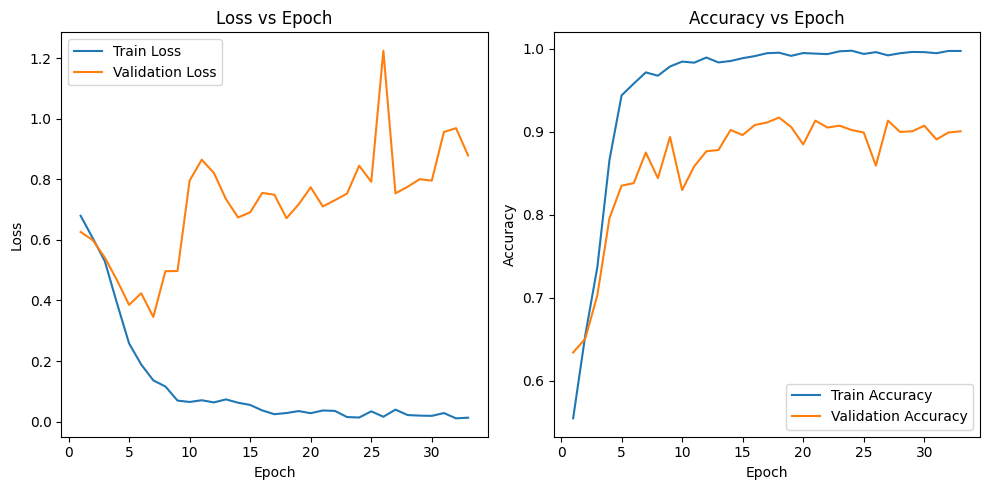

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Manually input the training and validation metrics from your provided logs
epochs = np.arange(1, 34)  # Since early stopping occurred at epoch 33

train_loss = [0.6795, 0.6056, 0.5293, 0.3910, 0.2582, 0.1887, 0.1362, 0.1160, 0.0695, 0.0650,
              0.0706, 0.0635, 0.0734, 0.0625, 0.0551, 0.0370, 0.0246, 0.0284, 0.0349, 0.0279,
              0.0368, 0.0354, 0.0151, 0.0136, 0.0340, 0.0162, 0.0396, 0.0218, 0.0199, 0.0191,
              0.0283, 0.0109, 0.0131]
val_loss = [0.6260, 0.5991, 0.5413, 0.4670, 0.3855, 0.4238, 0.3456, 0.4966, 0.4972, 0.7957,
            0.8646, 0.8212, 0.7346, 0.6740, 0.6909, 0.7551, 0.7490, 0.6715, 0.7171, 0.7734,
            0.7103, 0.7310, 0.7528, 0.8448, 0.7916, 1.2244, 0.7535, 0.7753, 0.8003, 0.7956,
            0.9561, 0.9688, 0.8785]
train_accuracy = [0.5550, 0.6549, 0.7373, 0.8662, 0.9439, 0.9580, 0.9716, 0.9676, 0.9787, 0.9846,
                  0.9833, 0.9895, 0.9836, 0.9853, 0.9887, 0.9912, 0.9947, 0.9953, 0.9915, 0.9949,
                  0.9942, 0.9936, 0.9970, 0.9977, 0.9938, 0.9960, 0.9921, 0.9947, 0.9962, 0.9960,
                  0.9947, 0.9974, 0.9974]
val_accuracy = [0.6343, 0.6509, 0.7035, 0.7961, 0.8352, 0.8382, 0.8751, 0.8442, 0.8939, 0.8299,
                0.8585, 0.8766, 0.8781, 0.9022, 0.8962, 0.9082, 0.9112, 0.9172, 0.9059, 0.8849,
                0.9135, 0.9052, 0.9074, 0.9022, 0.8992, 0.8593, 0.9135, 0.8999, 0.9007, 0.9074,
                0.8909, 0.8992, 0.9007]

# Plotting Loss vs Epoch
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs, train_loss, label='Train Loss')
plt.plot(epochs, val_loss, label='Validation Loss')
plt.title('Loss vs Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Plotting Accuracy vs Epoch
plt.subplot(1, 2, 2)
plt.plot(epochs, train_accuracy, label='Train Accuracy')
plt.plot(epochs, val_accuracy, label='Validation Accuracy')
plt.title('Accuracy vs Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, f1_score, precision_score, recall_score
from sklearn.utils.class_weight import compute_class_weight
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import (
    AutoTokenizer,
    AutoConfig,
    AutoModel,
    get_linear_schedule_with_warmup
)
from torch.optim import AdamW
from tqdm import tqdm
import warnings
from textaugment import EDA
import random
import nltk
from nltk.corpus import stopwords
from torch.nn import functional as F
from transformers.modeling_outputs import SequenceClassifierOutput

warnings.filterwarnings('ignore')

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Configuration - Updated with better parameters
MODEL_NAME = 'ai4bharat/indic-bert'
MAX_LEN = 128
BATCH_SIZE = 32
EPOCHS = 100  # Reduced to prevent overfitting
LEARNING_RATE = 2e-5  # Lower learning rate
NUM_WARMUP_STEPS = 100
WEIGHT_DECAY = 0.01
PATIENCE = 15
DROPOUT_RATE = 0.2  # Added dropout rate
GRADIENT_CLIP = 1.0  # Gradient clipping

# Download NLTK stopwords if needed
try:
    stopwords.words('english')
except LookupError:
    nltk.download('stopwords')

# Enhanced Model Architecture
class EnhancedIndicBertWithCNN(nn.Module):
    def __init__(self, model_name, num_labels):
        super().__init__()
        self.config = AutoConfig.from_pretrained(model_name)
        self.bert = AutoModel.from_pretrained(model_name)

        # More sophisticated CNN architecture
        self.conv1 = nn.Conv1d(self.config.hidden_size, 256, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm1d(256)
        self.conv2 = nn.Conv1d(256, 128, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm1d(128)
        self.conv3 = nn.Conv1d(128, 64, kernel_size=5, padding=2)  # Larger kernel
        self.bn3 = nn.BatchNorm1d(64)

        # Attention layer
        self.attention = nn.Sequential(
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 1),
            nn.Softmax(dim=1)
        )

        # Classifier with more layers
        self.classifier = nn.Sequential(
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Dropout(DROPOUT_RATE),
            nn.Linear(64, num_labels)
        )

        self.dropout = nn.Dropout(DROPOUT_RATE)
        self.init_weights()

    def init_weights(self):
        for module in [self.conv1, self.conv2, self.conv3, self.classifier]:
            if hasattr(module, 'weight') and module.weight is not None:
                nn.init.xavier_uniform_(module.weight)
            if hasattr(module, 'bias') and module.bias is not None:
                nn.init.constant_(module.bias, 0)

    def forward(self, input_ids=None, attention_mask=None, labels=None):
        outputs = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        sequence_output = outputs.last_hidden_state

        # CNN processing
        conv_input = sequence_output.permute(0, 2, 1)
        x = F.relu(self.bn1(self.conv1(conv_input)))
        x = self.dropout(x)
        x = F.relu(self.bn2(self.conv2(x)))
        x = self.dropout(x)
        x = F.relu(self.bn3(self.conv3(x)))
        x = self.dropout(x)

        # Attention mechanism
        attention_weights = self.attention(x.permute(0, 2, 1))
        attention_weights = attention_weights.permute(0, 2, 1)
        x = torch.bmm(attention_weights, x.permute(0, 2, 1)).squeeze(1)

        logits = self.classifier(x)

        loss = None
        if labels is not None:
            loss_fct = nn.CrossEntropyLoss()
            loss = loss_fct(logits.view(-1, self.config.num_labels), labels.view(-1))

        return SequenceClassifierOutput(
            loss=loss,
            logits=logits,
            hidden_states=outputs.hidden_states,
            attentions=outputs.attentions
        )

# Improved Dataset Class with better text cleaning
class HinglishDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

        # Preprocess texts and labels
        self._preprocess_data()

    def _preprocess_data(self):
        # Handle labels
        self.labels = [str(label) if not pd.isna(label) else 'nan' for label in self.labels]
        self.texts = [str(text) if not pd.isna(text) else '' for text in self.texts]

        # Clean texts
        self.texts = [self._clean_text(text) for text in self.texts]

        # Filter empty texts and invalid labels
        valid_indices = [i for i, (text, label) in enumerate(zip(self.texts, self.labels))
                        if text.strip() != '' and self._is_valid_label(label)]
        self.texts = [self.texts[i] for i in valid_indices]
        self.labels = [self.labels[i] for i in valid_indices]

    def _clean_text(self, text):
        # Basic cleaning
        text = text.lower().strip()
        # Remove special characters but keep Hinglish words
        text = ''.join(c if c.isalnum() or c.isspace() else ' ' for c in text)
        # Remove extra spaces
        return ' '.join(text.split())

    def _is_valid_label(self, label):
        try:
            _ = int(float(label))
            return True
        except ValueError:
            label = label.upper()
            return label in ['CAG', 'OAG', 'NAG', 'YES', 'NO']

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]

        # Convert label to integer
        try:
            label = int(float(label))
        except ValueError:
            label = label.upper()
            if label in ['CAG', 'OAG', 'NAG']:
                label_map = {'CAG': 0, 'OAG': 1, 'NAG': 2}
                label = label_map[label]
            elif label in ['YES', 'NO']:
                label = 1 if label == 'YES' else 0
            else:
                label = -1  # Should be filtered in _preprocess_data

        encoding = self.tokenizer.encode_plus(
            text,
            add_special_tokens=True,
            max_length=self.max_len,
            return_token_type_ids=False,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'label': torch.tensor(label, dtype=torch.long)
        }

# Enhanced Data Augmentation
class HinglishAugmenter:
    def __init__(self):
        self.stop_words = set(stopwords.words('english'))
        self.hinglish_swaps = {
            'hello': ['namaste', 'hi', 'hey'],
            'good': ['achha', 'badhiya', 'thik'],
            # Add more Hinglish specific swaps
        }

    def augment(self, text, label, augment_prob=0.4):
        if random.random() > augment_prob:
            return text, label

        methods = [
            self._synonym_replacement,
            self._random_swap,
            self._random_deletion,
            self._hinglish_swap
        ]
        augment_fn = random.choice(methods)

        try:
            augmented = augment_fn(text)
            return augmented if augmented else text, label
        except:
            return text, label

    def _synonym_replacement(self, text):
        words = text.split()
        n = max(1, int(0.1 * len(words)))
        indices = random.sample(range(len(words)), n)
        for i in indices:
            word = words[i]
            if word in self.hinglish_swaps:
                words[i] = random.choice(self.hinglish_swaps[word])
        return ' '.join(words)

    def _random_swap(self, text):
        words = text.split()
        if len(words) < 2:
            return text
        idx1, idx2 = random.sample(range(len(words)), 2)
        words[idx1], words[idx2] = words[idx2], words[idx1]
        return ' '.join(words)

    def _random_deletion(self, text, p=0.1):
        words = text.split()
        if len(words) < 2:
            return text
        return ' '.join([word for word in words if random.random() > p])

    def _hinglish_swap(self, text):
        words = text.split()
        for i, word in enumerate(words):
            if word in self.hinglish_swaps and random.random() < 0.3:
                words[i] = random.choice(self.hinglish_swaps[word])
        return ' '.join(words)

# Enhanced Data Loading with better validation - MODIFIED FOR HASOC DATASET
def load_data(file_path, task_type='binary'):
    df = pd.read_csv(file_path)

    # Validate and rename columns for HASOC dataset
    if 'moh_text' not in df.columns or 'hate' not in df.columns:
        raise ValueError("Dataframe must contain 'moh_text' and 'hate' columns")

    # Rename 'hate' column to 'label' to match expected format
    df = df.rename(columns={'hate': 'label'})

    # Clean text
    df['moh_text'] = df['moh_text'].astype(str).str.strip()
    df = df[df['moh_text'] != '']

    # Process labels based on task type
    if task_type == 'binary':
        df['label'] = df['label'].astype(str).str.strip().str.lower()
        valid_labels = {'yes', 'no', '1', '0', 'true', 'false'}
        df = df[df['label'].isin(valid_labels)]
        df['label'] = df['label'].map({
            'yes': 1, 'no': 0,
            '1': 1, '0': 0,
            'true': 1, 'false': 0
        })

    # Balance classes if needed
    if df['label'].nunique() > 1:
        min_samples = df['label'].value_counts().min()
        df = df.groupby('label').apply(lambda x: x.sample(min_samples)).reset_index(drop=True)

    # Apply enhanced data augmentation
    augmenter = HinglishAugmenter()
    augmented_data = []
    for _, row in df.iterrows():
        augmented_text, label = augmenter.augment(row['moh_text'], row['label'])
        augmented_data.append({'moh_text': augmented_text, 'label': label})

    augmented_df = pd.DataFrame(augmented_data)
    df = pd.concat([df, augmented_df]).reset_index(drop=True)

    return df[['moh_text', 'label']]

# Enhanced Training Function with early stopping and gradient clipping
def train_epoch(model, data_loader, optimizer, device, scheduler, n_examples, class_weights):
    model.train()
    losses = []
    correct_predictions = 0
    all_preds = []
    all_labels = []

    for d in tqdm(data_loader, desc="Training"):
        input_ids = d['input_ids'].to(device)
        attention_mask = d['attention_mask'].to(device)
        labels = d['label'].to(device)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )

        loss = outputs.loss
        logits = outputs.logits

        # Apply class weights
        if class_weights is not None:
            loss_fct = nn.CrossEntropyLoss(weight=class_weights)
            loss = loss_fct(logits.view(-1, model.config.num_labels), labels.view(-1))

        _, preds = torch.max(logits, dim=1)
        correct_predictions += torch.sum(preds == labels)
        losses.append(loss.item())

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

        # Gradient clipping and optimization
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRADIENT_CLIP)
        optimizer.step()
        scheduler.step()
        optimizer.zero_grad()

    accuracy = correct_predictions.double() / n_examples
    avg_loss = np.mean(losses)

    f1 = f1_score(all_labels, all_preds, average='weighted')
    precision = precision_score(all_labels, all_preds, average='weighted')
    recall = recall_score(all_labels, all_preds, average='weighted')

    return accuracy, avg_loss, f1, precision, recall

# Enhanced Evaluation Function
def eval_model(model, data_loader, device, n_examples, class_weights):
    model.eval()
    losses = []
    correct_predictions = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for d in tqdm(data_loader, desc="Evaluating"):
            input_ids = d['input_ids'].to(device)
            attention_mask = d['attention_mask'].to(device)
            labels = d['label'].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )

            loss = outputs.loss
            logits = outputs.logits

            # Apply class weights if needed
            if class_weights is not None:
                loss_fct = nn.CrossEntropyLoss(weight=class_weights)
                loss = loss_fct(logits.view(-1, model.config.num_labels), labels.view(-1))

            _, preds = torch.max(logits, dim=1)
            correct_predictions += torch.sum(preds == labels)
            losses.append(loss.item())

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    accuracy = correct_predictions.double() / n_examples if n_examples > 0 else 0
    avg_loss = np.mean(losses) if losses else float('inf')

    f1 = f1_score(all_labels, all_preds, average='weighted')
    precision = precision_score(all_labels, all_preds, average='weighted')
    recall = recall_score(all_labels, all_preds, average='weighted')

    return accuracy, avg_loss, f1, precision, recall, all_preds, all_labels

# Enhanced Main Training Function
def train_model(df_train, df_val, num_labels=2, model_save_path='enhanced_model.bin', task_name='Classification'):
    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

    # Calculate class weights with smoothing
    class_weights = None
    if num_labels > 1:
        class_weights = compute_class_weight(
            'balanced',
            classes=np.unique(df_train['label']),
            y=df_train['label']
        )
        class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)

    # Load enhanced model
    model = EnhancedIndicBertWithCNN(MODEL_NAME, num_labels)
    model = model.to(device)

    # Create data loaders
    train_data_loader = DataLoader(
        HinglishDataset(df_train['moh_text'].values, df_train['label'].values, tokenizer, MAX_LEN),
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=4
    )

    val_data_loader = DataLoader(
        HinglishDataset(df_val['moh_text'].values, df_val['label'].values, tokenizer, MAX_LEN),
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=4
    )

    # Optimizer with differential learning rates
    no_decay = ['bias', 'LayerNorm.weight']
    optimizer_grouped_parameters = [
        {
            'params': [p for n, p in model.named_parameters()
                      if not any(nd in n for nd in no_decay)],
            'weight_decay': WEIGHT_DECAY,
            'lr': LEARNING_RATE
        },
        {
            'params': [p for n, p in model.named_parameters()
                      if any(nd in n for nd in no_decay)],
            'weight_decay': 0.0,
            'lr': LEARNING_RATE * 0.1  # Lower LR for these params
        },
    ]
    optimizer = AdamW(optimizer_grouped_parameters, lr=LEARNING_RATE, eps=1e-8)

    # Scheduler with warmup
    total_steps = len(train_data_loader) * EPOCHS
    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=NUM_WARMUP_STEPS,
        num_training_steps=total_steps
    )

    # Training tracking with early stopping
    best_f1 = 0
    patience_counter = 0
    history = {
        'train_acc': [], 'train_loss': [], 'train_f1': [], 'train_precision': [], 'train_recall': [],
        'val_acc': [], 'val_loss': [], 'val_f1': [], 'val_precision': [], 'val_recall': []
    }

    for epoch in range(EPOCHS):
        print(f'Epoch {epoch + 1}/{EPOCHS}')
        print('-' * 10)

        train_acc, train_loss, train_f1, train_precision, train_recall = train_epoch(
            model, train_data_loader, optimizer, device, scheduler, len(df_train), class_weights
        )

        print(f'Train Loss: {train_loss:.4f} | Accuracy: {train_acc:.4f} | F1: {train_f1:.4f}')

        val_acc, val_loss, val_f1, val_precision, val_recall, val_preds, val_labels = eval_model(
            model, val_data_loader, device, len(df_val), class_weights
        )

        print(f'Val Loss: {val_loss:.4f} | Accuracy: {val_acc:.4f} | F1: {val_f1:.4f}')
        print('\nClassification Report:')
        print(classification_report(val_labels, val_preds))

        # Update history
        history['train_acc'].append(float(train_acc))
        history['train_loss'].append(float(train_loss))
        history['train_f1'].append(float(train_f1))
        history['train_precision'].append(float(train_precision))
        history['train_recall'].append(float(train_recall))

        history['val_acc'].append(float(val_acc))
        history['val_loss'].append(float(val_loss))
        history['val_f1'].append(float(val_f1))
        history['val_precision'].append(float(val_precision))
        history['val_recall'].append(float(val_recall))

        # Early stopping
        if val_f1 > best_f1:
            best_f1 = val_f1
            patience_counter = 0
            torch.save(model.state_dict(), model_save_path)
            print(f"Model saved with best F1: {best_f1:.4f}")
        else:
            patience_counter += 1
            if patience_counter >= PATIENCE:
                print(f"Early stopping after {PATIENCE} epochs without improvement")
                break

    return history

# Main Execution for HASOC dataset
def run_training():
    try:
        # Binary classification for HASOC dataset
        print("="*50)
        print("Training binary hate speech classification model on HASOC dataset...")
        print("="*50)
        binary_df = load_data('final_hasoc_cleaned.csv', task_type='binary')
        df_train, df_val = train_test_split(binary_df, test_size=0.2, random_state=42, stratify=binary_df['label'])
        binary_history = train_model(
            df_train, df_val, num_labels=2,
            model_save_path='enhanced_binary_model_hasoc.bin',
            task_name='Binary Hate Speech Classification (HASOC)'
        )

        # Plot training history
        if binary_history:
            plt.figure(figsize=(12, 6))
            plt.plot(binary_history['train_f1'], label='Train F1')
            plt.plot(binary_history['val_f1'], label='Validation F1')
            plt.title('Training History - HASOC Dataset')
            plt.xlabel('Epoch')
            plt.ylabel('F1 Score')
            plt.legend()
            plt.show()

        return binary_history

    except Exception as e:
        print(f"Error during training: {str(e)}")
        return None

if __name__ == "__main__":
    hasoc_history = run_training()

Using device: cuda
Training binary hate speech classification model on HASOC dataset...


config.json:   0%|          | 0.00/507 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/5.65M [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/135M [00:00<?, ?B/s]

Epoch 1/100
----------


...

Training: 100%|██████████| 255/255 [03:13<00:00,  1.32it/s]


Train Loss: 0.0202 | Accuracy: 0.9928 | F1: 0.9928


Evaluating: 100%|██████████| 64/64 [00:13<00:00,  4.61it/s]


Val Loss: 0.7717 | Accuracy: 0.9132 | F1: 0.9132

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.90      0.91      1020
           1       0.91      0.92      0.91      1020

    accuracy                           0.91      2040
   macro avg       0.91      0.91      0.91      2040
weighted avg       0.91      0.91      0.91      2040

Epoch 42/100
----------


Training:  98%|█████████▊| 249/255 [03:09<00:04,  1.29it/s]